# Gensim: BBC News Data LDA Topic Modeling using Gensim

In [1]:
%load_ext autoreload
%autoreload 2

import logging
import Gensim_topic_modeling_utils as topic_utils 

logging.basicConfig(level=logging.INFO)
_LOG = logging.getLogger(__name__)

/Users/tanayapravinjoshi/Assignments/Data605/Project_Gensim/gpsaggese.github.io/class_project/data605/Spring2026/projects/UmdTask420_DATA605_Spring2026_Gensim_topic_modeling/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Importing libraries 

import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

# Data loading and cleaning

Dataset used for this project is the BBC news data taken from Kaggle 
https://www.kaggle.com/datasets/hgultekin/bbcnewsarchive 

In [3]:
# Loading BBC news dataset into a pandas dataframe 

df = pd.read_csv('bbc-news-data.csv',sep='\t')
df.head()

,category,filename,title,content
0,business,001.txt,Ad sales boost Time Warner profit,Quarterly profits at US media giant TimeWarne...
1,business,002.txt,Dollar gains on Greenspan speech,The dollar has hit its highest level against ...
2,business,003.txt,Yukos unit buyer faces loan claim,The owners of embattled Russian oil giant Yuk...
3,business,004.txt,High fuel prices hit BA's profits,British Airways has blamed high fuel prices f...
4,business,005.txt,Pernod takeover talk lifts Domecq,Shares in UK drinks and food firm Allied Dome...


In [4]:
# Checking for duplicates 

df['title'].duplicated().sum()

np.int64(129)

In [5]:
# Dropping duplicates 

df = df.drop_duplicates(subset='title', keep='first').reset_index(drop=True)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2096 entries, 0 to 2095
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   category  2096 non-null   str  
 1   filename  2096 non-null   str  
 2   title     2096 non-null   str  
 3   content   2096 non-null   str  
dtypes: str(4)
memory usage: 65.6 KB


In [7]:
(df['content'] == "").sum()

np.int64(0)

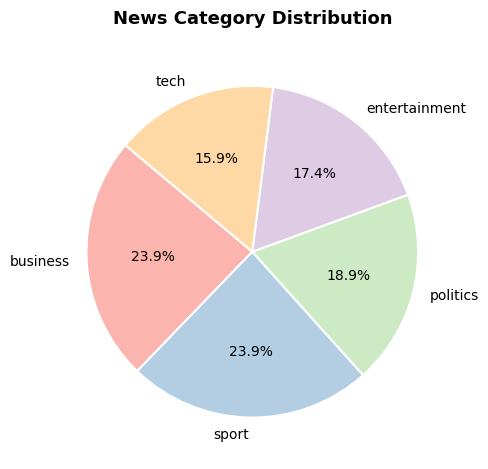

In [8]:
# Plotting news category distribution

fig, ax = plt.subplots(figsize=(5, 5))
counts = df['category'].value_counts()
ax.pie(
    counts,
    labels    = counts.index,
    autopct   = '%1.1f%%',
    colors    = plt.cm.Pastel1.colors,
    startangle= 140,
    wedgeprops= dict(edgecolor='white', linewidth=1.5)
)
ax.set_title("News Category Distribution", fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

# Data Pre-processing

Processing the data first as LDA cannot be implemented on raw data. This step involves cleaning and tokenizing texts followed by lemmatization and stop word removal. These tokens can then be processed by Gensim.

In [9]:
# Importing NLTK library along with stopwords, tokenzier and lemmatizer 
topic_utils.download_nltk_data()

In [10]:
# Tokenzing article content 

df['clean_tokens'] = topic_utils.preprocess_corpus(list(df['content']))

In [11]:
# Final cleaned dataset 

df.head()

,category,filename,title,content,clean_tokens
0,business,001.txt,Ad sales boost Time Warner profit,Quarterly profits at US media giant TimeWarne...,"[quarterly, profit, u, medium, giant, timewarn..."
1,business,002.txt,Dollar gains on Greenspan speech,The dollar has hit its highest level against ...,"[dollar, hit, highest, level, euro, almost, th..."
2,business,003.txt,Yukos unit buyer faces loan claim,The owners of embattled Russian oil giant Yuk...,"[owner, embattled, russian, oil, giant, yukos,..."
3,business,004.txt,High fuel prices hit BA's profits,British Airways has blamed high fuel prices f...,"[british, airway, blamed, high, fuel, price, d..."
4,business,005.txt,Pernod takeover talk lifts Domecq,Shares in UK drinks and food firm Allied Dome...,"[share, uk, drink, food, firm, allied, domecq,..."


# Topic Modeling

The processed documents are used to create a dictionary and corpus which are needed for LDA to map each word to an integer as LDA cannot operate on strings.

In [12]:
# Creating word dictionary out of cleaned tokens 
# This will be used to build the LDA model

docs = list(df['clean_tokens'])
word_dict = topic_utils.build_dictionary(docs)

INFO:gensim.corpora.dictionary:adding document #0 to Dictionary<0 unique tokens: []>
INFO:gensim.corpora.dictionary:built Dictionary<24135 unique tokens: ['account', 'adjust', 'advert', 'advertising', 'alexander']...> from 2096 documents (total 429319 corpus positions)
INFO:gensim.utils:Dictionary lifecycle event {'msg': "built Dictionary<24135 unique tokens: ['account', 'adjust', 'advert', 'advertising', 'alexander']...> from 2096 documents (total 429319 corpus positions)", 'datetime': '2026-05-07T23:00:46.043882', 'gensim': '4.4.0', 'python': '3.13.7 (v3.13.7:bcee1c32211, Aug 14 2025, 19:10:51) [Clang 16.0.0 (clang-1600.0.26.6)]', 'platform': 'macOS-26.3.1-arm64-arm-64bit-Mach-O', 'event': 'created'}
INFO:gensim.corpora.dictionary:discarding 22135 tokens: [('adjust', 5), ('advert', 25), ('alexander', 22), ('also', 1179), ('aol', 13), ('benefited', 6), ('bertelsmann', 1), ('bros', 4), ('buoyed', 5), ('catwoman', 1)]...
INFO:gensim.corpora.dictionary:keeping 2000 tokens which were in n

Vocabulary before filtering : 24135
Vocabulary after filtering  : 2000


In [13]:
# Building corpus using BoW representation of the documents so LDA can work with the documents mathematically 

corpus = topic_utils.build_corpus(docs, word_dict)
print("BoW for doc 1: ", corpus[0])

BoW for doc 1:  [(0, 2), (1, 2), (2, 1), (3, 1), (4, 1), (5, 1), (6, 1), (7, 1), (8, 1), (9, 1), (10, 1), (11, 1), (12, 1), (13, 1), (14, 1), (15, 1), (16, 1), (17, 1), (18, 1), (19, 2), (20, 1), (21, 1), (22, 2), (23, 2), (24, 1), (25, 1), (26, 1), (27, 1), (28, 1), (29, 2), (30, 1), (31, 1), (32, 1), (33, 1), (34, 1), (35, 2), (36, 1), (37, 1), (38, 1), (39, 1), (40, 1), (41, 3), (42, 1), (43, 1), (44, 1), (45, 1), (46, 1), (47, 2), (48, 1), (49, 1), (50, 1), (51, 2), (52, 1), (53, 1), (54, 1), (55, 1), (56, 4), (57, 1), (58, 1), (59, 1), (60, 1), (61, 1), (62, 1), (63, 1), (64, 1), (65, 1), (66, 1), (67, 1), (68, 1), (69, 1), (70, 1), (71, 1), (72, 1), (73, 1), (74, 1), (75, 1), (76, 1), (77, 1), (78, 1), (79, 2), (80, 1), (81, 9), (82, 1), (83, 4), (84, 1), (85, 1), (86, 1), (87, 2), (88, 4), (89, 1), (90, 1), (91, 1), (92, 2), (93, 4), (94, 1), (95, 1), (96, 1), (97, 2), (98, 1), (99, 1), (100, 1), (101, 1), (102, 3), (103, 1), (104, 1), (105, 1), (106, 2), (107, 1), (108, 1), (10

In [14]:
# Getting coherence values of LDA models for topic sizes between 10 and 20 

models, scores = topic_utils.compute_coherence_values(word_dict, corpus, docs, start=10, limit=20, step=1)

INFO:gensim.models.ldamodel:using autotuned alpha, starting with [np.float32(0.1), np.float32(0.1), np.float32(0.1), np.float32(0.1), np.float32(0.1), np.float32(0.1), np.float32(0.1), np.float32(0.1), np.float32(0.1), np.float32(0.1)]
INFO:gensim.models.ldamodel:using symmetric eta at 0.1
INFO:gensim.models.ldamodel:using serial LDA version on this node
INFO:gensim.models.ldamodel:running online (multi-pass) LDA training, 10 topics, 15 passes over the supplied corpus of 2096 documents, updating model once every 2000 documents, evaluating perplexity every 2096 documents, iterating 50x with a convergence threshold of 0.001000
INFO:gensim.models.ldamodel:PROGRESS: pass 0, at document #2000/2096
INFO:gensim.models.ldamodel:optimized alpha [np.float32(0.12432466), np.float32(0.12052968), np.float32(0.14072536), np.float32(0.11439702), np.float32(0.1224815), np.float32(0.11476155), np.float32(0.12472932), np.float32(0.12756082), np.float32(0.12217908), np.float32(0.13182092)]
INFO:gensim.mo

In [15]:
# Coherence scores for each topic size 

score_dict = {}
for i, cv in enumerate(scores):
    score_dict[i+10] = cv
    print(f"Num topics: {i+10:2d} | Coherence: {cv:.4f}")

Num topics: 10 | Coherence: 0.5689
Num topics: 11 | Coherence: 0.5420
Num topics: 12 | Coherence: 0.5317
Num topics: 13 | Coherence: 0.5311
Num topics: 14 | Coherence: 0.5212
Num topics: 15 | Coherence: 0.5670
Num topics: 16 | Coherence: 0.5669
Num topics: 17 | Coherence: 0.5308
Num topics: 18 | Coherence: 0.5582
Num topics: 19 | Coherence: 0.5459


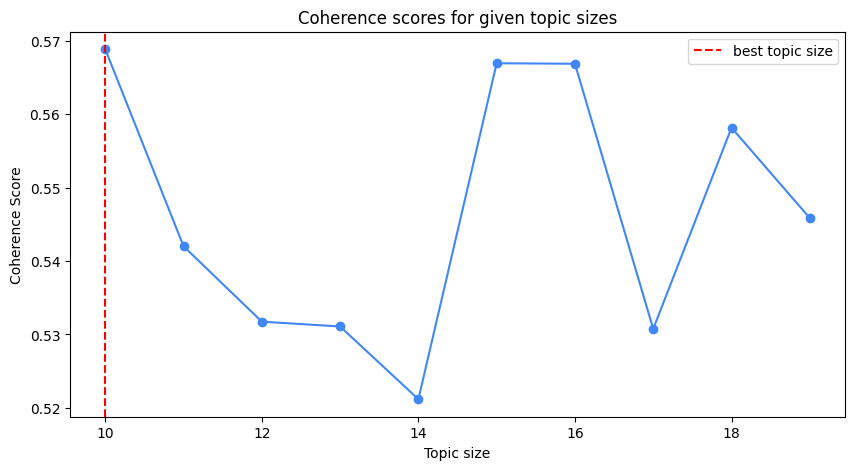

In [16]:
# Visualizing the coherence scores to pick the best topic size for the final model 

x = range(10,20)
best_topic = max(score_dict, key=score_dict.get)
plt.figure(figsize=(10,5))
plt.plot(x, scores, marker='o', color="#4287F7")
plt.axvline(x=best_topic, color='red', linestyle='--', label='best topic size')
plt.xlabel("Topic size")
plt.ylabel("Coherence Score")
plt.title("Coherence scores for given topic sizes")
plt.legend()
plt.show()

In [17]:
print(f"Best topic size: {best_topic} with coherence score {max(score_dict.values()):.4f}")

Best topic size: 10 with coherence score 0.5689


Hence, the best topic size is 10 as it gives the maximum coherence score of 0.56

In [18]:
# Building the final LDA model for topic size = 10 

lda_model = topic_utils.train_lda_model(corpus, word_dict, num_topics=10)

INFO:gensim.models.ldamodel:using autotuned alpha, starting with [np.float32(0.1), np.float32(0.1), np.float32(0.1), np.float32(0.1), np.float32(0.1), np.float32(0.1), np.float32(0.1), np.float32(0.1), np.float32(0.1), np.float32(0.1)]
INFO:gensim.models.ldamodel:using serial LDA version on this node
INFO:gensim.models.ldamodel:running online (multi-pass) LDA training, 10 topics, 20 passes over the supplied corpus of 2096 documents, updating model once every 2000 documents, evaluating perplexity every 0 documents, iterating 400x with a convergence threshold of 0.001000
INFO:gensim.models.ldamodel:PROGRESS: pass 0, at document #2000/2096
INFO:gensim.models.ldamodel:optimized alpha [np.float32(0.06253648), np.float32(0.060300082), np.float32(0.07586225), np.float32(0.056511063), np.float32(0.05786798), np.float32(0.054844074), np.float32(0.06058819), np.float32(0.064110585), np.float32(0.060862895), np.float32(0.068256654)]
INFO:gensim.models.ldamodel:merging changes from 2000 documents 

LDA model trained with 10 topics


In [19]:
topic_utils.inspect_topics(lda_model, corpus, df, title_column="title")

  TOPIC 0

  Top 5 words:
    0.0106  - film
    0.0071  - sale
    0.0068  - england
    0.0060  - back
    0.0058  - made

  Top 5 representative articles:
    1. [1.00] Italy 17-28 Ireland
    2. [1.00] O'Driscoll saves Irish blushes
    3. [1.00] Original Exorcist to be screened
    4. [1.00] Tomlinson stays focused on Europe
    5. [1.00] Claxton hunting first major medal

  TOPIC 1

  Top 5 words:
    0.0453  - music
    0.0197  - radio
    0.0169  - firm
    0.0153  - technology
    0.0128  - song

  Top 5 representative articles:
    1. [1.00] Format wars could 'confuse users'
    2. [0.99] Peer-to-peer nets 'here to stay'
    3. [0.98] Speak easy plan for media players
    4. [0.98] Court mulls file-sharing future
    5. [0.91] Mobiles get set for visual radio

  TOPIC 2

  Top 5 words:
    0.0391  - mobile
    0.0308  - phone
    0.0198  - broadband
    0.0186  - service
    0.0130  - uk

  Top 5 representative articles:
    1. [1.00] Broadband soars in 2004
    2. [1.00] Ceb

In [20]:
# Defining topic labels for the 10 topics found by LDA 

topic_labels = {
    9: "government_labour",
    8: "laptop_computers",
    7: "search_engine",
    6: "gaming",
    5: "company_leaks",
    4: "spam_hackers",
    3: "cybersecurity",
    2: "broadband_net_services", 
    1: "mobile_advancement",
    0: "sports"
}

In [21]:
df = topic_utils.assign_topics(
    df           = df,
    corpus       = corpus,
    model        = lda_model,
    topic_labels = topic_labels
)

In [22]:
df.head()

,category,filename,title,content,clean_tokens,cluster_id,topic_confidence,topic_label
0,business,001.txt,Ad sales boost Time Warner profit,Quarterly profits at US media giant TimeWarne...,"[quarterly, profit, u, medium, giant, timewarn...",0,0.3809,sports
1,business,002.txt,Dollar gains on Greenspan speech,The dollar has hit its highest level against ...,"[dollar, hit, highest, level, euro, almost, th...",9,0.7353,government_labour
2,business,003.txt,Yukos unit buyer faces loan claim,The owners of embattled Russian oil giant Yuk...,"[owner, embattled, russian, oil, giant, yukos,...",9,0.7723,government_labour
3,business,004.txt,High fuel prices hit BA's profits,British Airways has blamed high fuel prices f...,"[british, airway, blamed, high, fuel, price, d...",9,0.4996,government_labour
4,business,005.txt,Pernod takeover talk lifts Domecq,Shares in UK drinks and food firm Allied Dome...,"[share, uk, drink, food, firm, allied, domecq,...",9,0.8203,government_labour


In [23]:
# Visualizing topics with pyLDAvis

topic_utils.get_pyldavis_visualization(lda_model, corpus, word_dict)

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
0      0.182766 -0.169781       1        1  25.877462
1     -0.107420  0.204621       2        1   2.935398
2     -0.179231 -0.188728       3        1   4.575590
3     -0.200670 -0.039962       4        1   4.493598
4      0.355984  0.030988       5        1   8.518006
5      0.114981  0.329528       6        1   3.909859
6      0.008532 -0.242773       7        1   5.581694
7     -0.231361  0.092504       8        1   3.311127
8     -0.065490 -0.036053       9        1   4.051068
9      0.121910  0.019656      10        1  36.746197, topic_info=         Term         Freq        Total Category  logprob  loglift
1126     game  1284.000000  1284.000000  Default  30.0000  30.0000
808    mobile   540.000000   540.000000  Default  29.0000  29.0000
70      music   515.000000   515.000000  Default  28.0000  28.0000
96    service   785.000000   785.000000  Default  27.0000  27.0000
854     phone   433.000000   433.000000  Default  26.0000  26.0000
...       ...          ...          ...      ...      ...      ...
23       deal   326.109288   430.447770  Topic10  -5.7497   0.7235
243     group   389.319697   668.294836  Topic10  -5.5726   0.4608
66     market   409.001473   768.749325  Topic10  -5.5233   0.3701
38       firm   428.804574   918.924146  Topic10  -5.4760   0.2389
388        uk   398.602798   972.784187  Topic10  -5.5490   0.1089

[597 rows x 6 columns], token_table=      Topic      Freq     Term
term                          
1373      2  0.095524   access
1373      3  0.367014   access
1373      4  0.110607   access
1373      6  0.095524   access
1373      7  0.050276   access
...     ...       ...      ...
1761      5  0.096608  younger
1761      7  0.410584  younger
1761     10  0.362280  younger
1898      1  0.949395  zealand
1898      5  0.044158  zealand

[2027 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10])

The graph shows that topics 1 and 10 are huge and almost overlapping which means both topics cover similar themes and the model struggled to cleanly separate them. However, given that the topic 10 has top words like government, minister, labour, party and topic 1 has words related to UK sports, we can say these are indeed distinct topics. 

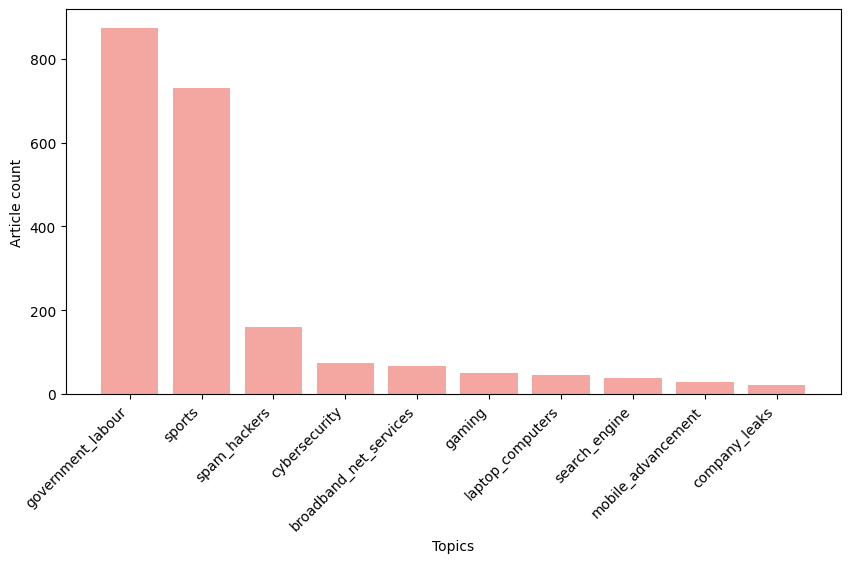

In [24]:
# Visualizing topic distribution 

topic_counts = df['topic_label'].value_counts()
plt.figure(figsize=(10,5))
plt.bar(topic_counts.index, topic_counts, color="#F3A7A0")
plt.xlabel("Topics")
plt.ylabel("Article count")
plt.xticks(rotation=45, ha='right')
plt.show()

As we also saw above, government_labour is the largest topic followed by sports. This matches with the distribution of the categories present in the original dataset where the largest category is goverment followed by sports.

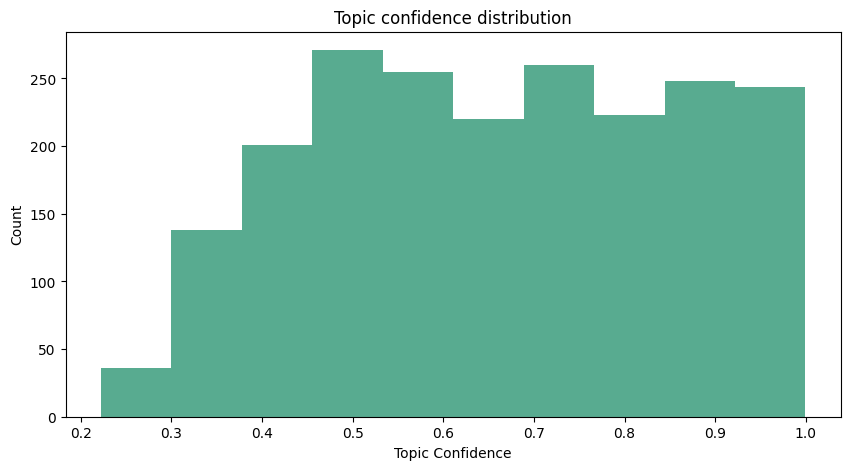

In [25]:
# Visualizing topic confidence distribution

plt.figure(figsize=(10,5))
plt.hist(df['topic_confidence'], color="#58AB90")
plt.xlabel("Topic Confidence")
plt.ylabel("Count")
plt.title("Topic confidence distribution")
plt.show()

The distribution of the topic confidence shows that the majority of the documents fall within the 0.4 and 1.0 confidence range. As a result, the graph looks more like a plateau rather than a sharp right-skewed peak. This pattern is largely due the two dominating topics which account for nearly 62% of the dataset. Since BBC news articles frequently intersect multiple domains, LDA correctly captures this ambiguity through the majority of mid-range confidence scores. Topics that were easily distinguishable have a high confidence score between 0.8 and 1.0.

In [26]:
# Saving the topic assignment for downstream processing 

df.to_csv('processed/news_articles_topic_assignment.csv')

# Sentiment Analysis

Sentiment analysis will reveal the tone of the topics which will indicate which topics are polar, which are neutral, and which topics lean towards a single sentiment. RoBERTa model is used for this purpose as the model is trained on news data and works well with longform articles. 

In [27]:
df = pd.read_csv('processed/news_articles_topic_assignment.csv')

In [28]:
df.head()

,Unnamed: 0,category,filename,title,content,clean_tokens,cluster_id,topic_confidence,topic_label
0,0,business,001.txt,Ad sales boost Time Warner profit,Quarterly profits at US media giant TimeWarne...,"['quarterly', 'profit', 'u', 'medium', 'giant'...",0,0.3809,sports
1,1,business,002.txt,Dollar gains on Greenspan speech,The dollar has hit its highest level against ...,"['dollar', 'hit', 'highest', 'level', 'euro', ...",9,0.7353,government_labour
2,2,business,003.txt,Yukos unit buyer faces loan claim,The owners of embattled Russian oil giant Yuk...,"['owner', 'embattled', 'russian', 'oil', 'gian...",9,0.7723,government_labour
3,3,business,004.txt,High fuel prices hit BA's profits,British Airways has blamed high fuel prices f...,"['british', 'airway', 'blamed', 'high', 'fuel'...",9,0.4996,government_labour
4,4,business,005.txt,Pernod takeover talk lifts Domecq,Shares in UK drinks and food firm Allied Dome...,"['share', 'uk', 'drink', 'food', 'firm', 'alli...",9,0.8203,government_labour


In [29]:
# Defining sentiment analysis model using RoBERTa 

sentiment_pipeline = topic_utils.load_sentiment_model()

INFO:httpx:HTTP Request: HEAD https://huggingface.co/cardiffnlp/twitter-roberta-base-sentiment-latest/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/cardiffnlp/twitter-roberta-base-sentiment-latest/3216a57f2a0d9c45a2e6c20157c20c49fb4bf9c7/config.json "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/cardiffnlp/twitter-roberta-base-sentiment-latest/resolve/main/model.safetensors "HTTP/1.1 404 Not Found"
INFO:httpx:HTTP Request: GET https://huggingface.co/api/models/cardiffnlp/twitter-roberta-base-sentiment-latest "HTTP/1.1 200 OK"
Loading weights: 100%|██████████| 201/201 [00:00<00:00, 48479.30it/s]
RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.pooler.dense.weight     | UNEXPECTED |  | 
roberta.pooler.dense.bias     

In [30]:
# Getting sentiment label, score and confidence score for each article content 

results = topic_utils.get_sentiment_batch(df['content'].tolist(), sentiment_pipeline)
sentiment_result = pd.DataFrame(results)

In [31]:
df = pd.concat([df, sentiment_result], axis=1)

In [32]:
df.head()

,Unnamed: 0,category,filename,title,content,clean_tokens,cluster_id,topic_confidence,topic_label,sentiment_label,sentiment_confidence,sentiment_score
0,0,business,001.txt,Ad sales boost Time Warner profit,Quarterly profits at US media giant TimeWarne...,"['quarterly', 'profit', 'u', 'medium', 'giant'...",0,0.3809,sports,positive,0.8153,0.8153
1,1,business,002.txt,Dollar gains on Greenspan speech,The dollar has hit its highest level against ...,"['dollar', 'hit', 'highest', 'level', 'euro', ...",9,0.7353,government_labour,neutral,0.7710,0.0000
2,2,business,003.txt,Yukos unit buyer faces loan claim,The owners of embattled Russian oil giant Yuk...,"['owner', 'embattled', 'russian', 'oil', 'gian...",9,0.7723,government_labour,neutral,0.7953,0.0000
3,3,business,004.txt,High fuel prices hit BA's profits,British Airways has blamed high fuel prices f...,"['british', 'airway', 'blamed', 'high', 'fuel'...",9,0.4996,government_labour,neutral,0.6350,0.0000
4,4,business,005.txt,Pernod takeover talk lifts Domecq,Shares in UK drinks and food firm Allied Dome...,"['share', 'uk', 'drink', 'food', 'firm', 'alli...",9,0.8203,government_labour,neutral,0.8968,0.0000


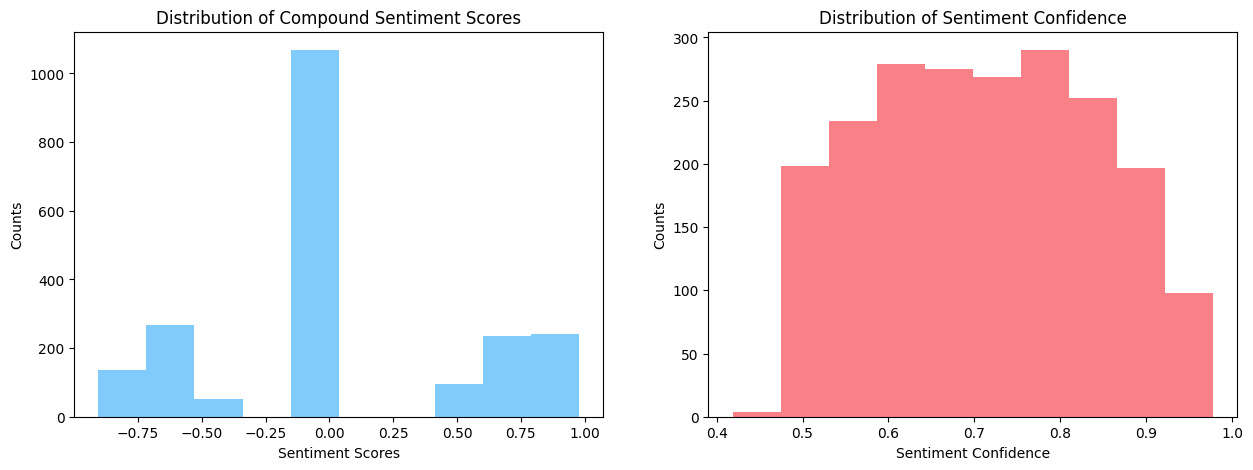

In [33]:
# Visualising distribution of sentiment scores (left) and confidence score (right)

fig, ax = plt.subplots(1,2,figsize=(15,5))
ax[0].hist(df['sentiment_score'], color="#80CBF9")
ax[0].set_xlabel("Sentiment Scores")
ax[0].set_ylabel("Counts")
ax[0].set_title("Distribution of Compound Sentiment Scores")

ax[1].hist(df['sentiment_confidence'], color="#F98086")
ax[1].set_xlabel("Sentiment Confidence")
ax[1].set_ylabel("Counts")
ax[1].set_title("Distribution of Sentiment Confidence")
plt.show()

The sentiment scores show that while the majority of the articles are neutral, the rest are either extremely negative or extremely positive. The confidence score is between 0.45 to 0.80, most of the scores are mid to high range which means the model is moderately to highly confident in the classification. The visualization of topics vs sentiment will reveal if the topics themselves are polar or the extremely negative or positive articles are present in every topic.

In [34]:
df['sentiment_label'].value_counts()

sentiment_label
neutral     1068
positive     572
negative     456
Name: count, dtype: int64

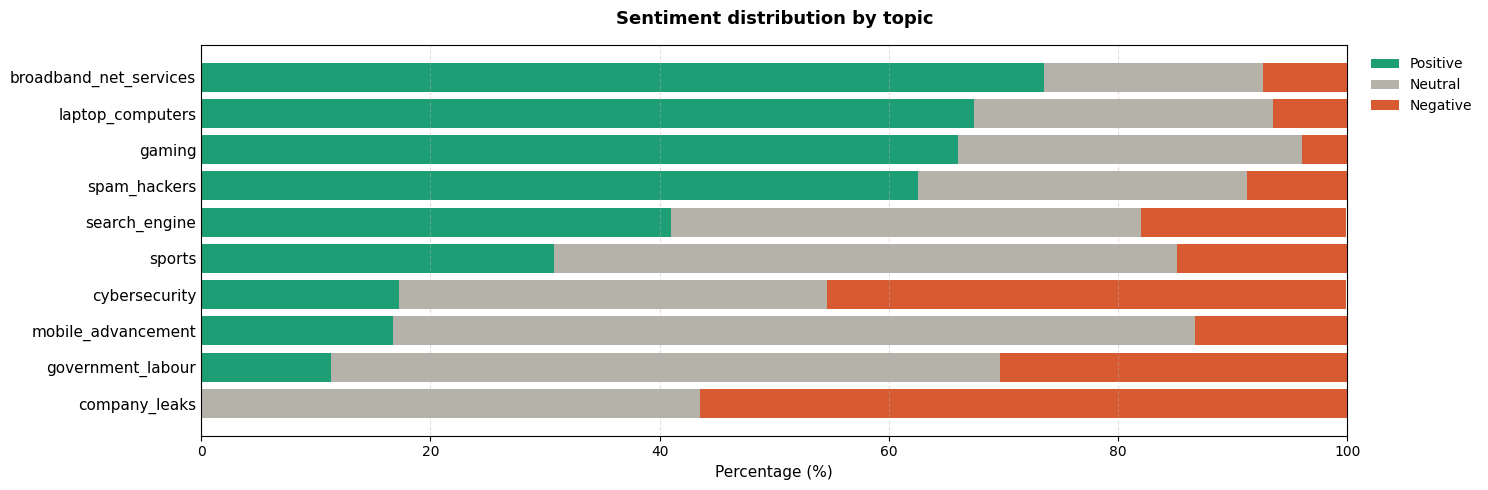

In [35]:
# Visualizing % of each sentiment label within a topic 

dist_vis = topic_utils.sentiment_dist_vis(df)
plt.tight_layout()
plt.show()

Hence, broadband_net_services has mostly positive articles whereas company_leaks has around 50% negative and 50% neutral articles making it the only topic with no positive articles within it. Interestingly, neutral articles are dominant in topics with low to none positive articles i.e they are more neutral and negative. 

In [36]:
# Calculating average sentiment for each topic 

bubble_data = df.groupby('topic_label').agg(sentiment=('sentiment_score', 'mean'), count=('sentiment_score', 'count')).reset_index()
bubble_data

,topic_label,sentiment,count
0,broadband_net_services,0.494282,68
1,company_leaks,-0.361626,23
2,cybersecurity,-0.197273,75
3,gaming,0.485476,50
4,government_labour,-0.115576,874
5,laptop_computers,0.469846,46
6,mobile_advancement,0.040293,30
7,search_engine,0.152221,39
8,spam_hackers,0.440588,160
9,sports,0.132122,731


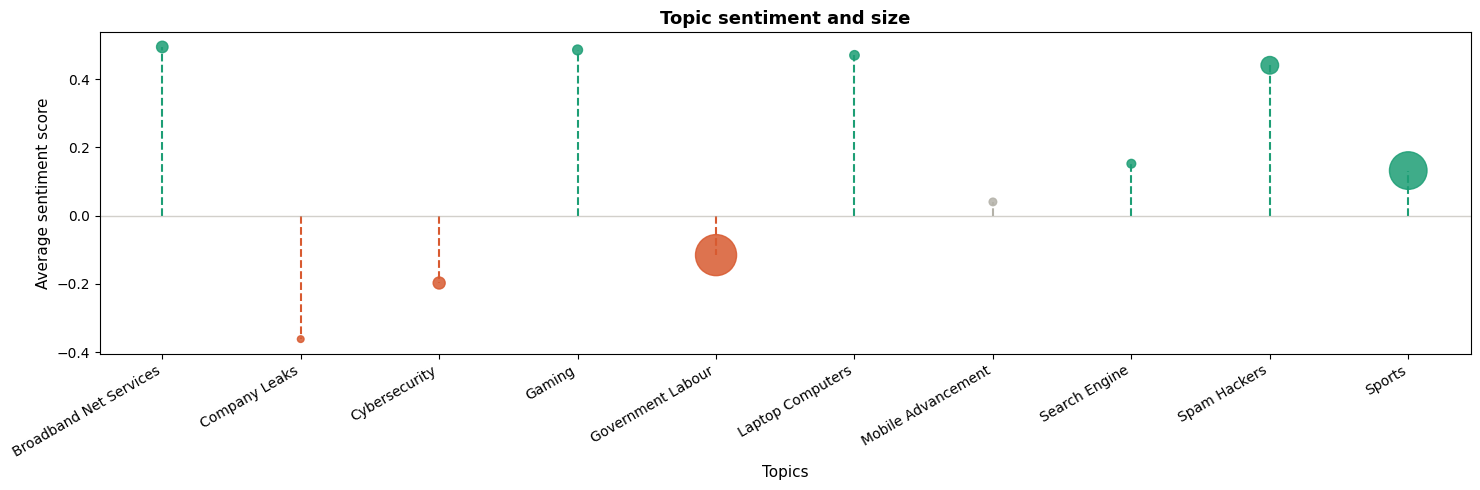

In [37]:
# Visualizing topic size x average sentiment 

topic_size_vis = topic_utils.topic_size_sentiment_vis(df)
plt.tight_layout()
plt.show()

The graph presents some interesting results. Government Labour is the largest topic and mean negative sentiment. Company leaks is a small topic however it is also the most negative meaning there are not many articles but when they are appear they are strongly negative. Similarly, broadband net services is a small topic but with the highest positive sentiment. Sports is also a large topic but with positive average sentiment. It is interesting to note that both the largest topics have polar sentiments but mid-range average sentiments. 

The main takeaway here is that size does not correlate with the sentiment.

In [38]:
# Calculating the polarity of each topic i.e. percentage of extremely negative and extremely positive articles 
# Polarity is calculated using 2 × min(% strongly positive, % strongly negative) 

polarity_data = topic_utils.calculate_topic_polarity(df)

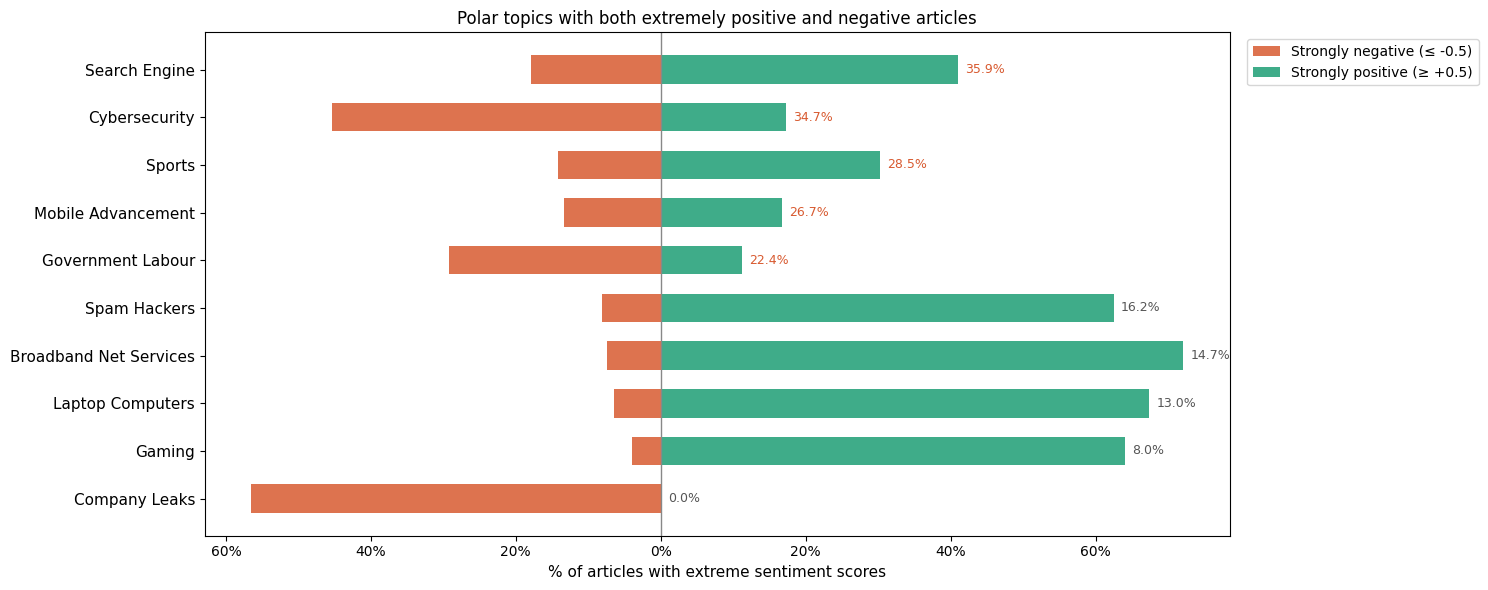

In [39]:
# Visualizing polarity of each topic 

topic_polarity_vis = topic_utils.topic_polarity_vis(polarity_data)
plt.tight_layout()
plt.show()

Interestingly, the Cybersecurity topic is a small topic however it has the highest polarity at 36.4% meaning 36.4% of the articles show genuine polarity i.e there are both extremely positive and negative articles. Sports and government labour are also interesting topics depicting polarity as both are the largest topics in the dataset. Company leaks, being the most negative topic only has extremely negative articles exhibiting no polarity.

# Result

## Topic Modeling 

This project applied Latent Dirichlet Allocation (LDA) using Gensim to a dataset of 2000 BBC News articles, identifying 10 distinct topics through rigorous data preprocessing including tokenziation, stopword removal, lemmatization, and vocabulary filtering to approximately 2000 tokens. Optimal topic size was determined using coherence scores for each topic size between 10 and 20, picking the topic size with the highest coherence score which was 10 with the score of 0.53 which is reasonable for news dataset where articles might span multiple topics. The two dominant topics are Sports and Government Labour together amounting for over 60% of the dataset. The remaining topics are smaller but clearly distinct. 

## Sentiment Analysis 

Sentiment analysis was done using RoBERTa as it is able to handle large news content for calculating sentiment. The sentiment distribution is trimodal with most of the articles being neutral, however, rest of the articles are either extremely negative or extremely positive Government Labour emerged as the largest yet negative topic, while tech-oriented topics such as Gaming, Broadband and Laptop Computers exhibited consistently positive sentiment. Polarity analysis, quantified as 2 × min(% strongly positive, % strongly negative), revealed that Cybersecurity (36.4%) and Search Engine (35.0%) were the most genuinely polarized topics with substantial representation on both extreme sentiments, whereas Company Leaks scored 0.0% polarity, confirming it as consistently negative rather than truly polarized.
